# Unsupervised Learning with K-Means and PCA

This is a starter notebook for the assignment, as outlined in the accompanying README file. Learners are expected to complete and deliver all their work for this portion of the assignment within this notebook.

In [1]:
# run this only once and then comment it out/delete the cell
! pip install ucimlrepo

Load dataset and combine features/targets


In [2]:
# import the dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets


Explain what the dataset contains, number of rows/columns, missing values

In [3]:
X.head()
y.head()

,Region
0,3
1,3
2,3
3,3
4,3


Preview first 5 rows

In [5]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=y)

MessageError: Error: credential propagation was unsuccessful

In [6]:
# Step 1: Explore data structure
print("Data info:")
X.info()  # check column types and non-null counts

print("\nSummary statistics:")
X.describe()  # see min, max, mean, std

print("\nCheck for missing values:")
X.isnull().sum()  # ensure no missing data

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB

Summary statistics:

Check for missing values:


,0
Channel,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


Describe observations

In [8]:
from sklearn.preprocessing import StandardScaler

# Step 1b: Preprocessing - Standardize features for clustering
# Only scale the spending features (exclude Channel and Region)
features = X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Confirm scaled features shape
print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (440, 7)


Scale features

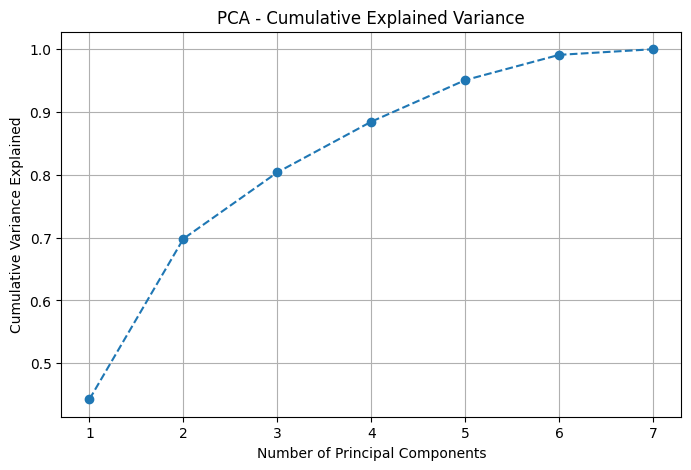

PC1: 0.4427
PC2: 0.6982
PC3: 0.8039
PC4: 0.8846
PC5: 0.9508
PC6: 0.9910
PC7: 1.0000


In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

# Print variance explained
for i, var in enumerate(cumulative_variance):
    print(f"PC{i+1}: {var:.4f}")

Explain why scaling is necessary for PCA/KMeans

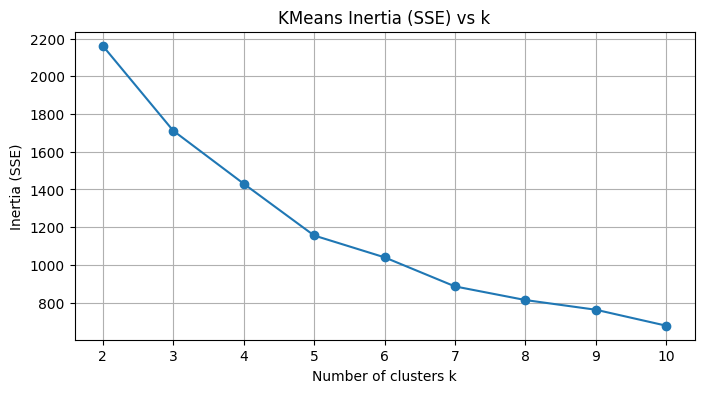

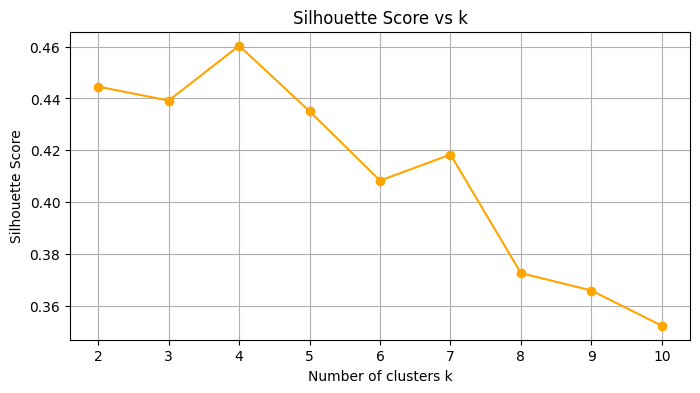

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step 3: Find optimal number of clusters using SSE and Silhouette
sse = []
silhouette_scores = []

k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot SSE (Elbow method)
plt.figure(figsize=(8,4))
plt.plot(k_range, sse, marker='o')
plt.title('KMeans Inertia (SSE) vs k')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (SSE)')
plt.grid(True)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8,4))
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [14]:
# Apply KMeans with chosen k
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
kmeans_final.fit(X_scaled)

# Assign clusters
X['Cluster_Scaled'] = kmeans_final.labels_

# Check cluster sizes
X['Cluster_Scaled'].value_counts()

,count
Cluster_Scaled,
1,297
0,130
2,13


In [16]:
# Choose number of PCs that retain ~90-95% variance
n_components = 3  # replace with your chosen number based on scree plot
pca_reduced = PCA(n_components=n_components)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

# KMeans on PCA-reduced data
kmeans_pca = KMeans(n_clusters=best_k, random_state=42)
kmeans_pca.fit(X_pca_reduced)

# Assign PCA cluster labels
X['Cluster_PCA'] = kmeans_pca.labels_

# Silhouette scores comparison
sil_scaled = silhouette_score(X_scaled, kmeans_final.labels_)
sil_pca = silhouette_score(X_pca_reduced, kmeans_pca.labels_)

print(f"Silhouette Score - Scaled Data: {sil_scaled:.4f}")
print(f"Silhouette Score - PCA-Reduced Data: {sil_pca:.4f}")

Silhouette Score - Scaled Data: 0.4392
Silhouette Score - PCA-Reduced Data: 0.4757


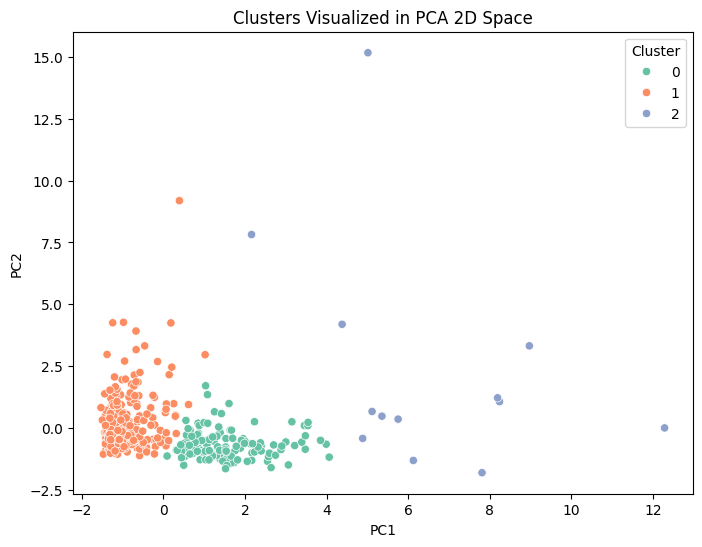

In [18]:
# Use first 2 PCs for 2D visualization
import seaborn as sns

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=X['Cluster_PCA'], palette='Set2')
plt.title('Clusters Visualized in PCA 2D Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [22]:
import pandas as pd

# Contribution of features to PC1 and PC2
components = pd.DataFrame(pca_2d.components_, columns=wholesale_customers.data.feature_names, index=['PC1','PC2'])
components

,0,1,2,3,4,5,6
PC1,0.428115,-0.026050,0.474424,0.536683,-0.029971,0.524370,0.164528
PC2,-0.205686,0.512403,0.206574,-0.007175,0.594700,-0.119524,0.533346


In [24]:
# Average spending per cluster
cluster_summary = X.groupby('Cluster_PCA').mean()
cluster_summary

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster_Scaled
Cluster_PCA,,,,,,,,
0,1.952756,7198.566929,9292.566929,14480.377953,1376.094488,6240.850394,1559.102362,0.047244
1,1.033333,13436.310000,3043.720000,3712.826667,3626.356667,723.310000,1234.976667,0.970000
2,1.846154,25770.769231,35160.384615,41977.384615,6844.538462,19867.384615,7880.307692,2.000000
